In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

print(X.shape)
print(y.shape)

(178, 13)
(178,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
post_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

post_model.fit(X_train, y_train)

y_pred_post = post_model.predict(X_test)

print("Post Pruning Accuracy:",
      accuracy_score(y_test, y_pred_post))

Post Pruning Accuracy: 0.9444444444444444


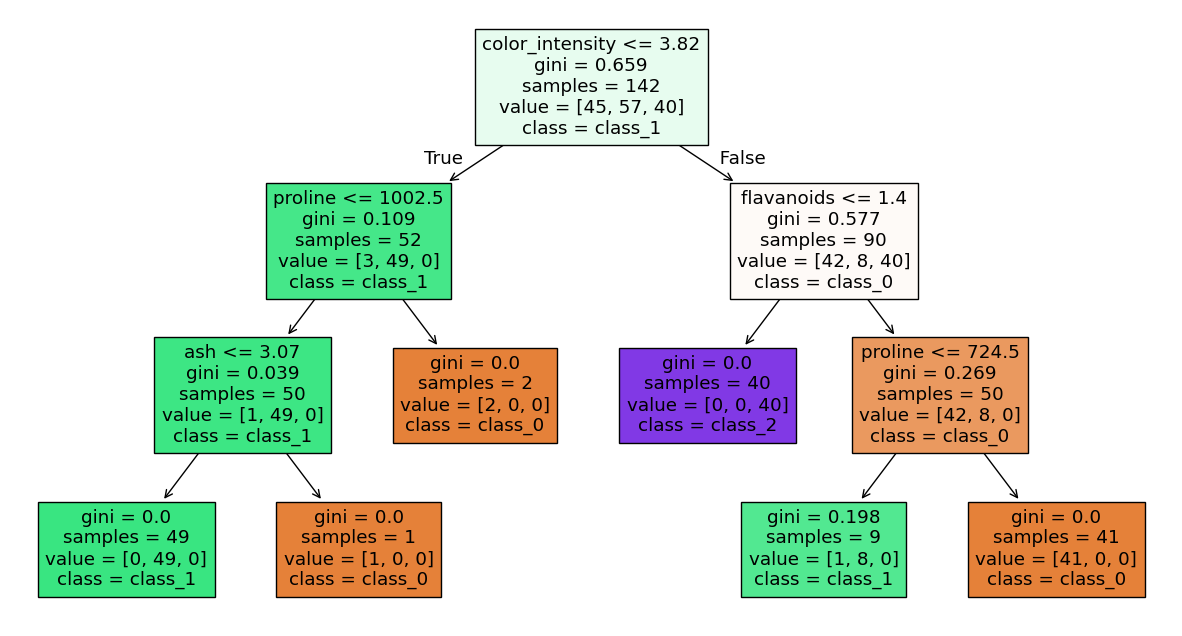

In [7]:
plt.figure(figsize=(15,8))

plot_tree(
    post_model,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True
)

plt.show()

In [8]:
pre_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42
)

pre_model.fit(X_train, y_train)

y_pred_pre = pre_model.predict(X_test)

print("Pre Pruning Accuracy:",
      accuracy_score(y_test, y_pred_pre))

Pre Pruning Accuracy: 0.9166666666666666


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)